**_#1.字符串解码_**

此题的巧妙之处在于使用curr_sum与curr_str来存储会遇到的数字与字符，而不是直接将其加入到栈中，正确的做法是当需要二者入栈的时候，处理到新的字符串（即遇到[时）再将其入栈。

    char.isdigit()#用来判断一个字符串是不是数字

In [ ]:
class Solution(object):
    def decodeString(self, s):
        """
        :type s: str
        :rtype: str
        """
        st=[]
        curr_num=0
        curr_str=""''
        for char in s:
            if char.isdigit():
                curr_num=10*curr_num+int(char)
            elif char=='[':#当遇到左括号时，意味值要处理下一个字符串了，先将当前字符串压栈并将下一个字符出现的次数压栈
                st.append(curr_num)
                st.append(curr_str)
                curr_num=0
                curr_str=""''
            elif char==']':#遇到右括号意味着字符串处理完毕，从堆栈中取出以前的字符串与数字进行合并
                num=st.pop()#不能使用curr_num = stack.pop(),因为这样的话会导致下一次遇到数字的时候出现大问题。比如当]5这种情况，因为遇到']'所以curr_num初值不为0，在遇到5之后curr_num会进一步变大
                pre=st.pop()
                curr_str=pre+num*curr_str
            else:
                curr_str+=char
        return curr_str

**_#2.最小栈_**

In [ ]:
class MinStack(object):

    def __init__(self):
        self.stack = []
    def push(self, val):
        if self.stack:
            self.stack.append((val,min(val,self.stack[-1][1])))#压入元素时，同时将当前元素与压入这个元素后当前的最小值作为一个元组压入，使得弹出与获取最小得到简化。
        else:
            self.stack.append((val,val))
    def pop(self):
        return self.stack.pop()
    def top(self):
        return self.stack[-1][0]
    def getMin(self):
        return self.stack[-1][1]

**_#3.每日温度（单调栈）_**

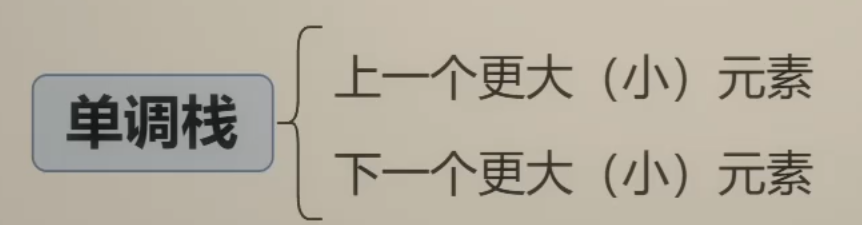

_**__上一个更大更小是通过单调栈的属性判断出来的，下一个更大更小是通过while循环中的比较判断出来的__**_

判断单调栈是递增还是递减就看在什么情况下会弹栈就行

此题的求解要特别留意数组中每个元素的索引值的作用，用索引值相减来得到天数，不需要依靠中间的值，在压栈的时候压入对应的索引值比直接压入数值更有意义

**_及时取出无用数据，保证栈中数据有序_**
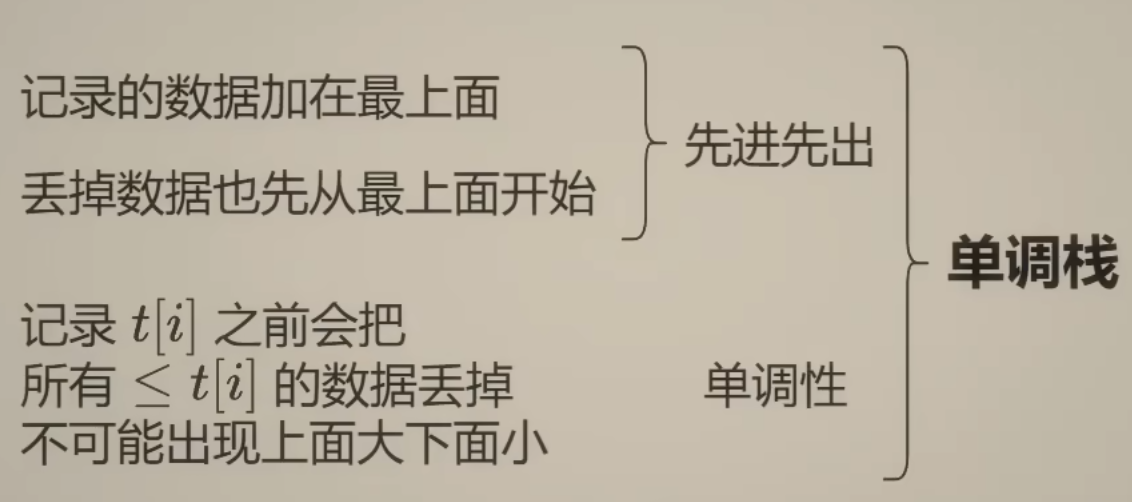

In [1]:
#从左到右
class Solution(object):
    def dailyTemperatures(self, temperatures):
        """
        :type temperatures: List[int]
        :rtype: List[int]
        """
        n = len(temperatures)
        stack = []
        res = [0]*n
        for index,i in enumerate(temperatures):
            while stack and i > temperatures[stack[-1]]:#留意比较过程中的前置条件，如果栈为空的话比较毫无意义
                pop = stack.pop()
                res[pop] = index - pop
            stack.append(index)

        return res

In [ ]:
#从右往左
#如果后入栈的元素大于等于先入栈的元素，那么先入栈的元素不可能作为左边元素遇到的第一个最大的值，因此直接从栈中取出即可。

**_#4.接雨水问题_**

找下一个最大元素，再找的过程中填坑

In [ ]:
class Solution:
    def trap(self, height) -> int:
        n = len(height)
        stack = []
        num = 0
        for i in range(n):#单调递减（从栈尾到栈顶）
            while stack and height[i] >= height[stack[-1]]:#相同元素只压一次
                bottom = height[stack.pop()]
                if not stack:#这种情况一般是两根柱子连在一起或者两片水连起来了
                    break
                #如果不为空那么一定存在比弹出元素更大的值，因此构成了一个坑，我们的目的就是去填坑
                h = min(height[i],height[stack[-1]]) - bottom
                num += h * (i - stack[-1] -1)
            stack.append(i)
        return num

**_#5.柱状图中最大的矩形_**

思想：枚举每个高度，找到它左右两边最小的值

记住两个-1操作

In [ ]:
class Solution:
    def largestRectangleArea(self, heights) -> int:
        heights.append(-1)  # 最后大火收汁，用 -1 把栈清空
        stack = [-1]#维护的是单调递增的栈
        max_area = 0
        for right,h in enumerate(heights):
            while len(stack) > 1 and heights[stack[-1]] >= h:#两个数相等的时候保留最新的值
                height = heights[stack.pop()]#矩形的高度
                left = stack[-1]
                max_area = max(max_area,height * (right-left-1))
            stack.append(right)
        return max_area